In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
import json
import re
import pickle
from collections import Counter
from tqdm import tqdm
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
from itertools import combinations


def save_pkl(tgt_list, svg_path):
    with open(svg_path, "wb") as f:
        pickle.dump(tgt_list, f)

def load_pkl(path) :
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

In [ ]:
from pathlib import Path
import matplotlib.font_manager as fm
fpath=Path('filepath')
arial_font = fm.FontProperties(fname=fpath)

fm.fontManager.addfont(fpath)

plt.rcParams['font.family']=arial_font.get_name()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
label_map = {0: "admiration",
    1: "amusement",
    2: "anger",
    3: "annoyance",
    4: "approval",
    5: "caring",
    6: "confusion",
    7: "curiosity",
    8: "desire",
    9: "disappointment",
    10: "disapproval",
    11: "disgust",
    12: "embarrassment",
    13: "excitement",
    14: "fear",
    15: "gratitude",
    16: "grief",
    17: "joy",
    18: "love",
    19: "nervousness",
    20: "optimism",
    21: "pride",
    22: "realization",
    23: "relief",
    24: "remorse",
    25: "sadness",
    26: "surprise",
    27: "neutral"
}

In [ ]:
def analyze_emotions_sentence_by_sentence(selftext):
    sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?)\s', selftext)
    predicted_emotions = []
    sent_emo_pairs = []

    for sentence in sentences:
        sentence = sentence.lower()
        # Tokenize the sentence
        encoded_input = tokenizer.encode_plus(sentence, return_tensors='tf', truncation=True, max_length=512, pad_to_max_length=True)

        # Perform emotion analysis
        outputs = model(encoded_input['input_ids'], attention_mask=encoded_input['attention_mask'])

        # Get the predicted label
        predicted_label = tf.argmax(outputs[0], axis=1).numpy()[0]

        # Map the predicted label to the corresponding emotion
        predicted_emotion = label_map.get(predicted_label, "unknown")
        predicted_emotions.append(predicted_emotion)
        #sent_emo_pairs.append((sentence, predicted_label))

    return predicted_emotions

def emotion_dataframe(selftexts):
    all_emotions = []
    mom_column = []
    dad_column = []

    for selftext in selftexts:
        emotions = analyze_emotions_sentence_by_sentence(selftext)
        print(emotions)
        emotion_counts = dict((emotion, emotions.count(emotion)) for emotion in set(emotions))
        all_emotions.append(emotion_counts)

        mom_column.append(int(any(word in selftext.lower() for word in ['mom', 'mother', 'mommy', 'mum'])))
        dad_column.append(int(any(word in selftext.lower() for word in ['dad', 'father', 'papa', 'daddy'])))

    df = pd.DataFrame(all_emotions).fillna(0)
    df['mom'] = mom_column
    df['dad'] = dad_column

    return df

## Load dataset

In [ ]:
new_df = pd.read_csv("./updated_asianParentStories_submissions.csv")
# new_df = new_df[["author",	"created_utc",	"title",	"selftext", "subreddit",	"score","num_comments"]]

In [ ]:
# temp = predicted_emotions[10]
# temp_dict = {for emo }
from collections import Counter

def word_presence(text, words):
    return int(any(word in text.lower() for word in words))

def temp_dict_all_create(label_map, temp_dict):
  temp_dict_all = {}
  for label in label_map.values() :
    if label not in temp_dict.keys() :
      temp_dict_all[label] = 0
    else:
      temp_dict_all[label] = temp_dict[label]
  return temp_dict_all

if __name__ == '__main__' :

  # subsample_size = 50 # Specify the number of rows to select randomly
  # subsample_df = new_df.sample(n=subsample_size, random_state=42)  # Randomly select rows from the DataFrame
  # selftext = subsample_df["selftext"].astype(str).tolist()
  selftext = new_df["selftext"].astype(str).tolist()
  # Prepare the progress bar
  pbar = tqdm( desc="Analyzing Emotions")

  mom_list = ['mom', 'mother', 'mommy', 'mum']
  dad_list = ['dad', 'father', 'papa', 'daddy']

  mom_flags = []
  dad_flags = []
  predicted_emotions = []
  # all_sent_emo_pairs = []
  batch_size = 20
  for i in range(0, len(selftext), batch_size):
      batch = selftext[i:i+batch_size]
      # Analyze emotions for the selftext batch
      temp_emotions = []
      # temp_sent_emo_pairs = []
      for sents in batch :

        predicted_emotions_sents = analyze_emotions_sentence_by_sentence(sents)
        temp_emotions.append(predicted_emotions_sents)
        # temp_sent_emo_pairs.append(sent_emo_pairs)


        sents = sents.lower()
        mom_flags.append(word_presence(sents, mom_list))
        dad_flags.append(word_presence(sents, dad_list))


      predicted_emotions.extend(temp_emotions)
      # all_sent_emo_pairs.extend(temp_sent_emo_pairs)

      # Update the progress bar
      pbar.update(len(batch))

  # Close the progress bar
  pbar.close()
'''
  emotion_df = pd.DataFrame(columns = label_map.values())
  for emotions in predicted_emotions:
    temp_dict = dict(Counter(emotions))
    temp_dict_all = temp_dict_all_create(label_map, temp_dict)
    # print(temp_dict_all)
    #append by row
    emotion_df.loc[len(emotion_df.index)] = list(temp_dict_all.values())

  #concat dataframe
  subsample_df = pd.concat([new_df.reset_index(drop=True), emotion_df], axis=1)
  subsample_df['mom'] = mom_flags
  subsample_df['dad'] = dad_flags
'''

In [ ]:
def get_heatmap(df, svg_name = None):
  df_np = df.to_numpy()
  df_trans = df_np.transpose()
  heatmap_prep = np.matmul(df_trans, df_np)

  plt.imshow(heatmap_prep,cmap = "hot")
  plt.colorbar()
  plt.tight_layout()
  if svg_name != None:
    plt.savefig(svg_name)
  plt.show()



In [ ]:
all_df = pd.read_csv("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/asianParents_all_new_emotion_df.csv")
all_df

,Unnamed: 0,author,created_utc,title,selftext,subreddit,score,num_comments,admiration,amusement,...,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,mom,dad
0,0,[deleted],2012-06-06 20:17:51,Korean parents and colleges,I didn't witness this firsthand but I was told...,AsianParentStories,47,28,1,0,...,0,0,0,0,0,0,0,4,0,0
1,1,BarbSueRoberts,2012-06-06 17:49:48,Asian parents full of contradictions.,My parents would tell me that I was getting fa...,AsianParentStories,33,12,0,0,...,0,0,0,0,0,0,0,5,0,0
2,2,wakaba,2012-06-06 11:18:47,Re: Lying,My mom used to tell my brother and I that we'l...,AsianParentStories,6,0,0,0,...,0,0,0,0,0,0,0,4,1,0
3,3,[deleted],2012-06-06 09:23:12,"I'm Asian, AMA",I love talking about Asian things. Did I menti...,AsianParentStories,0,5,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Shell058,2012-06-06 08:19:04,What is a rapacon?,A friend of mine has a Thai mother who has the...,AsianParentStories,41,4,0,1,...,0,0,0,0,0,0,0,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31139,31139,snnak87,2022-12-31 18:38:38,"New years eve dinner, mom acting up",I swear to god I’m not making this up. I was t...,AsianParentStories,7,8,0,0,...,0,0,0,0,0,1,0,4,1,0
31140,31140,somkkeshav555,2022-12-31 18:47:31,Writing a letter they never read,"For me, I wrote a letter recently to my parent...",AsianParentStories,7,7,0,0,...,0,0,4,0,0,0,0,3,1,1
31141,31141,Few_Statistician1496,2022-12-31 19:45:11,Asian parents destroying relationships,I’m in my mid-thirties and completely at my wi...,AsianParentStories,13,7,0,0,...,0,0,2,0,0,4,0,9,1,0
31142,31142,lnguyen0315,2022-12-31 19:48:30,"Mom's getting older, retiring without savings,...","Hi. I think a lot of millenials can relate, es...",AsianParentStories,6,8,0,0,...,1,0,1,0,0,1,0,7,1,0


In [ ]:
asianParents_all_new_emotion_df = pd.concat([new_df, emo_parent_only_df], axis=1)
asianParents_all_new_emotion_df

### Unorganized order

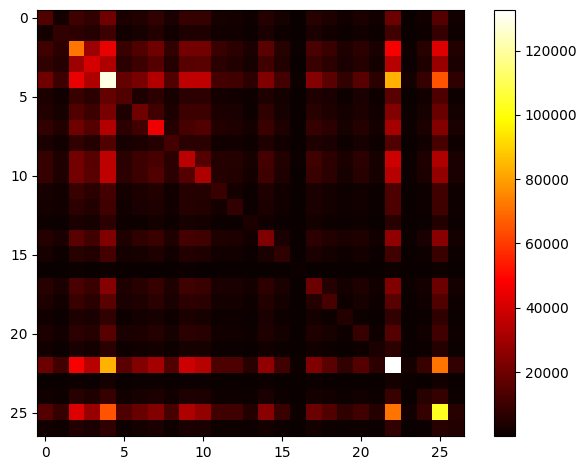

In [ ]:
emo_df = pd.read_csv("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/asianParents_all_emotion_only_df.csv")
emo_all_df = emo_df.iloc[:,1:-1]

get_heatmap(emo_all_df)

## Correlation final graph run from here pos-neg order

In [ ]:
emo_df = pd.read_csv("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/asianParents_all_emotion_only_df.csv")
emo_all_df = emo_df.iloc[:,1:-1]

In [ ]:
emo_organ_labels = ["admiration",
"amusement",
"approval",
"caring",
"curiosity",
"desire",
"excitement",
"gratitude",
"joy",
"love",
"optimism",
"pride",
"realization",
"relief",
"surprise",
                    #neutral
"anger",
"annoyance",
"confusion",
"disappointment",
"disapproval",
"disgust",
"embarrassment",
"fear",
"grief",
"nervousness",
"remorse",
"sadness"]

emo_organ_dicts = {idx:emo for idx, emo in enumerate(emo_organ_labels)}

emo_all_organ_df = emo_all_df[emo_organ_labels]

In [ ]:
def extract_nonzero(emo_list) :
  return [key for key, val in enumerate(emo_list) if val != 0 ]

if __name__ == '__main__':

  final_list = []
  only_emo_list = []
  for i in tqdm(range(len(emo_all_organ_df))) :
    #each row
    temp_emo_list = emo_all_organ_df.iloc[i].to_list()
    non_zero_idx = extract_nonzero(temp_emo_list)
    only_emo_list.extend(non_zero_idx)
    combis = list(combinations(non_zero_idx,2))
    final_list.extend(combis)

100%|██████████| 31144/31144 [00:01<00:00, 17740.78it/s]


In [ ]:
# pair_counter = Counter(final_list)
pair_counter = {key: round(val/len(pair_counter),2) for key, val in pair_counter.items()}
normal_counter = {key: round(val/len(pair_counter),2) for key, val in pair_counter.items()}

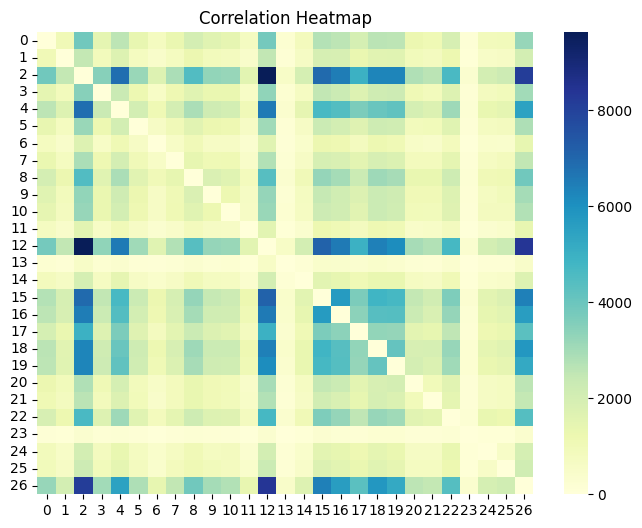

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
# pairs = {
#     (0, 2): 3906,
#     (0, 15): 2731,
#     (0, 18): 2605,
#     (2, 15): 6952,
#     (2, 18): 6304
# }

pairs = pair_counter

# Find unique nodes
nodes = sorted(set(n for pair in pairs for n in pair))

# Create an empty matrix
size = len(nodes)
matrix = np.zeros((size, size))

# Fill the matrix with frequencies
for (i, j), frequency in pairs.items():
    idx_i, idx_j = nodes.index(i), nodes.index(j)
    matrix[idx_i, idx_j] = frequency
    matrix[idx_j, idx_i] = frequency  # Symmetric for undirected graph

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, xticklabels=nodes, yticklabels=nodes, cmap="YlGnBu")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Coocurrence Matrix
get_heatmap(emo_all_organ_df, "/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/figs/emo_organized_heatmap.jpeg")

In [ ]:
emo_all_organ_df


emo_organ_labels_correct = [
"amusement",
"excitement",
"joy",
"love",
"desire",
"optimism",
"caring",
"pride",
"admiration",
"gratitude",
"relief",
"approval",
#neutral
"realization",
"surprise",
"curiosity",
"confusion",
"fear",
"nervousness",
"remorse",
"embarrassment",
"disappointment",
"sadness",
"grief",
"disgust",
"anger",
"annoyance",
"disapproval",
]


reorderd_emo_all_organ_df = emo_all_organ_df[emo_organ_labels_correct]

In [ ]:
def get_corr_graph(data, svg_name = None):

  heatmap = plt.pcolor(data)
  plt.rcParams["figure.figsize"] = [20, 20]
  # for y in range(data.shape[0]):
  #     for x in range(data.shape[1]):
  #         plt.text(x + 0.5, y + 0.5, '%.4f' % data.iloc[y, x],
  #                 horizontalalignment='center',
  #                 verticalalignment='center',
  #                 )
  plt.colorbar(heatmap)
  # plt.tight_layout()
  if svg_name != None:
    plt.savefig(svg_name)
  plt.show()


### get correlation heatmap

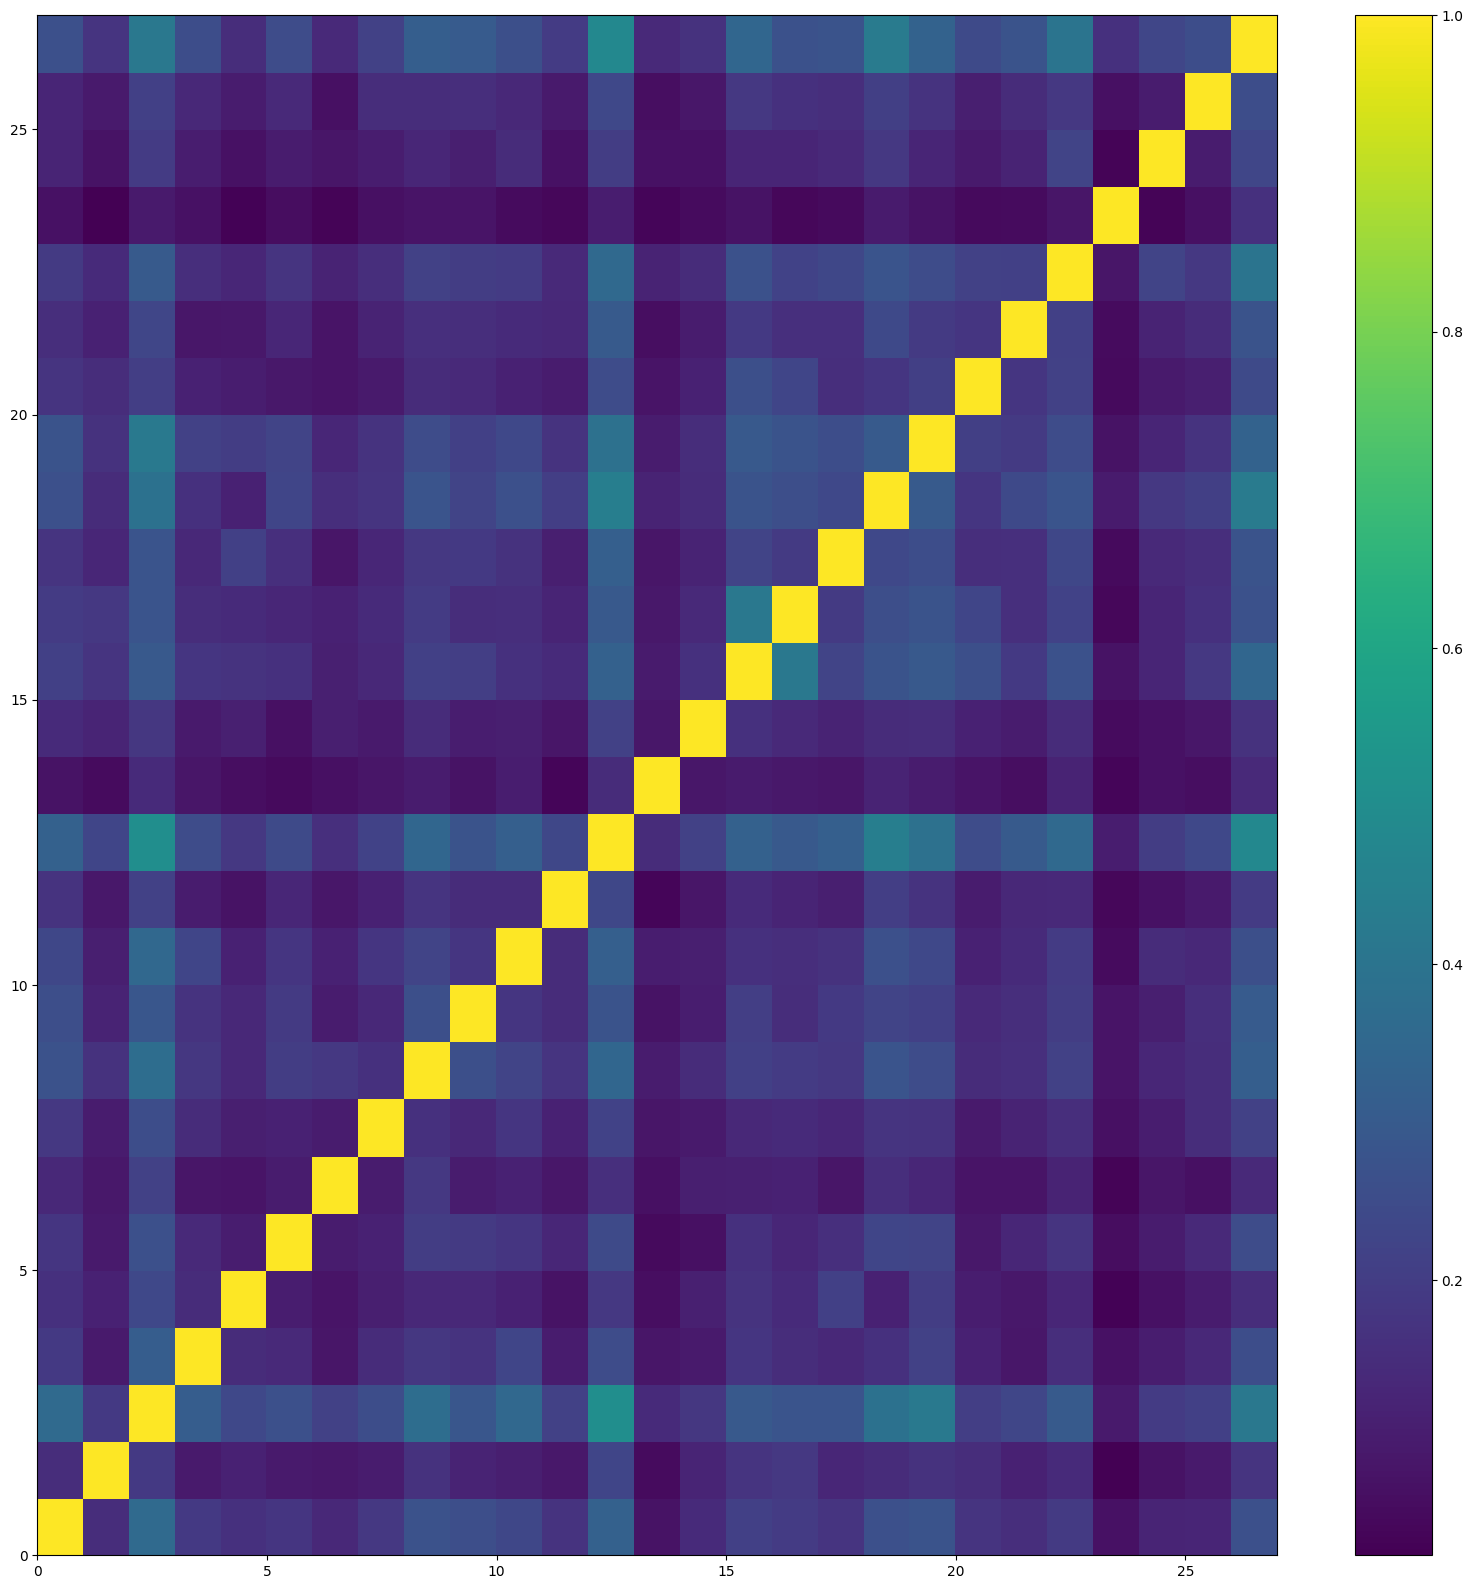

In [ ]:
# get_corr_graph(emo_all_organ_df.corr(),"/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/corr_heatmap.png" )
get_corr_graph(emo_all_organ_df.corr() ,"/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/figs/corr_heatmap.jpeg")

<ipython-input-71-58200c0aafb4>:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


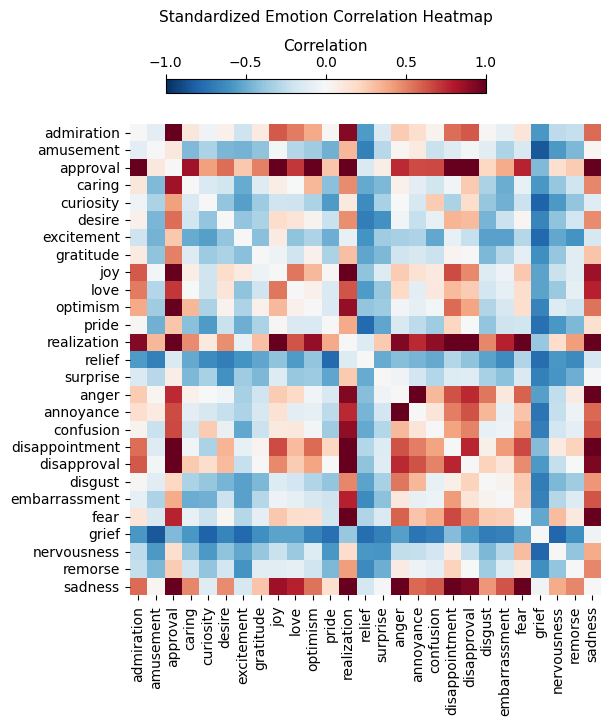

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Standardized correlation
corr = emo_all_organ_df.corr()
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)
mean_val = np.nanmean(corr_no_diag.values)
std_val = np.nanstd(corr_no_diag.values)
scaled_corr = (corr - mean_val) / std_val
scaled_corr = np.clip(scaled_corr, -2, 2) / 2
np.fill_diagonal(scaled_corr.values, 0)

# Step 2: Create figure and heatmap
fig, ax = plt.subplots(figsize=(8, 7))
heatmap = sns.heatmap(
    scaled_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar=False,
    ax=ax
)

# Step 3: Add smaller colorbar manually above heatmap
# [left, bottom, width, height] in figure coordinates (0-1)
cbar_ax = fig.add_axes([0.3, 0.91, 0.4, 0.02])  # narrower and slimmer
cbar = fig.colorbar(
    heatmap.get_children()[0],
    cax=cbar_ax,
    orientation='horizontal'
)
cbar.set_label("Correlation", fontsize=11)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')

# Final touch
plt.suptitle("Standardized Emotion Correlation Heatmap", y=1.03, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


<ipython-input-29-0381d7b97696>:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


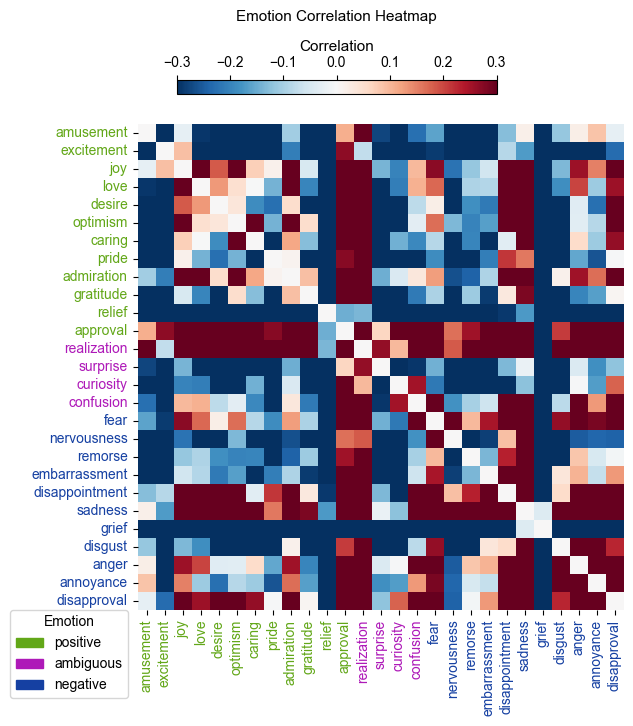

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

# === Step 1: Clean correlation matrix ===
corr = reorderd_emo_all_organ_df.corr(method='pearson')
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)
mean_val = np.nanmean(corr_no_diag.values)
std_val = np.nanstd(corr_no_diag.values)
scaled_corr = (corr - mean_val) / std_val
scaled_corr = np.clip(scaled_corr, -2, 2) / 2
np.fill_diagonal(scaled_corr.values, 0)


# === Step 2: Sentiment groups & colors ===
sentiment_map = {
    "positive": ["amusement","excitement", "joy","love","desire","optimism","caring","pride","admiration","gratitude","relief","approval"],
    "ambiguous": ["realization","surprise","curiosity","confusion"],
    "negative": ["fear","nervousness","remorse","embarrassment","disappointment","sadness","grief","disgust","anger","annoyance","disapproval"]
}
color_dict = {
    "positive": "#62a718",    # green
    "ambiguous": "#ae19b8",   # yellow
    "negative": "#1540a2"     # blue
}

# === Step 3: Match emotion to sentiment color ===
def get_sentiment_and_color(emotion):
    for s, emos in sentiment_map.items():
        if emotion in emos:
            return s, color_dict[s]
    return "unknown", "#d3d3d3"

emotions = corr.columns.tolist()
sentiments, colors = zip(*[get_sentiment_and_color(e) for e in emotions])

# === Step 4: Plot ===

# Step 2: Create figure and heatmap
fig, ax = plt.subplots(figsize=(8, 7))
heatmap = sns.heatmap(
    scaled_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    square=True,
    cbar=False,
    ax=ax
)

# Step 3: Add smaller colorbar manually above heatmap
# [left, bottom, width, height] in figure coordinates (0-1)
cbar_ax = fig.add_axes([0.3, 0.91, 0.4, 0.02])  # narrower and slimmer
cbar = fig.colorbar(
    heatmap.get_children()[0],
    cax=cbar_ax,
    orientation='horizontal'
)
cbar.set_label("Correlation", fontsize=11)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')

# === Step 5: Sentiment bars ===
for idx, color in enumerate(colors):
    # Top bar (above x-axis)
    ax.add_patch(plt.Rectangle((idx, -0.8), 1, 0.3, color=color, linewidth=0))
    # Left bar (left of y-axis)
    ax.add_patch(plt.Rectangle((-0.8, idx), 0.3, 1, color=color, linewidth=0))

# === Step 6: Color tick labels by sentiment ===
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for tick_label, color in zip(ax.get_xticklabels(), colors):
    tick_label.set_color(color)
    tick_label.set_fontweight("bold")
for tick_label, color in zip(ax.get_yticklabels(), colors):
    tick_label.set_color(color)
    tick_label.set_fontweight("bold")

# === Step 7: Legend ===
legend_patches = [
    Patch(color=color_dict["positive"], label="positive"),
    Patch(color=color_dict["ambiguous"], label="ambiguous"),
    Patch(color=color_dict["negative"], label="negative"),
]
ax.legend(
    handles=legend_patches,
    title="Emotion", #Sentiment
    # loc="lower left", #upper left
    bbox_to_anchor=(-0.02, 0),
    borderaxespad=0
)

# === Finalize ===
# Final touch
plt.suptitle("Emotion Correlation Heatmap", y=1.03, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("filepath", dpi=800)
plt.show()

In [ ]:
corr = reorderd_emo_all_organ_df.corr()

# Mask diagonal (self-correlation = 1)
np.fill_diagonal(corr.values, np.nan)

min_corr = corr.min().min()
max_corr = corr.max().max()

print("Minimum correlation:", min_corr)
print("Maximum correlation:", max_corr)

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

# Sort by correlation value
print("Top 10 strongest correlations:")
print(corr_pairs.sort_values(ascending=False).head(20))

print("\nTop 10 weakest correlations:")
print(corr_pairs.sort_values().head(10))

Minimum correlation: 0.02616713576932756
Maximum correlation: 0.5046283364213158
Top 10 strongest correlations:
approval        realization       0.504628
realization     sadness           0.480996
                disappointment    0.437374
disappointment  sadness           0.426112
approval        disapproval       0.421555
                sadness           0.415862
anger           annoyance         0.415324
fear            sadness           0.401822
approval        disappointment    0.388696
realization     disapproval       0.384638
joy             approval          0.369808
admiration      approval          0.359617
realization     fear              0.355563
optimism        approval          0.350940
sadness         anger             0.344642
joy             realization       0.343336
sadness         disapproval       0.327403
realization     anger             0.324451
admiration      realization       0.323167
realization     confusion         0.318194
dtype: float64

Top 10 weake

In [ ]:
print(len(scaled_corr.columns), len(sentiment_labels))
print(scaled_corr.columns.difference(emotions))  # Check for mismatch

27 27
Index([], dtype='object')


## Network

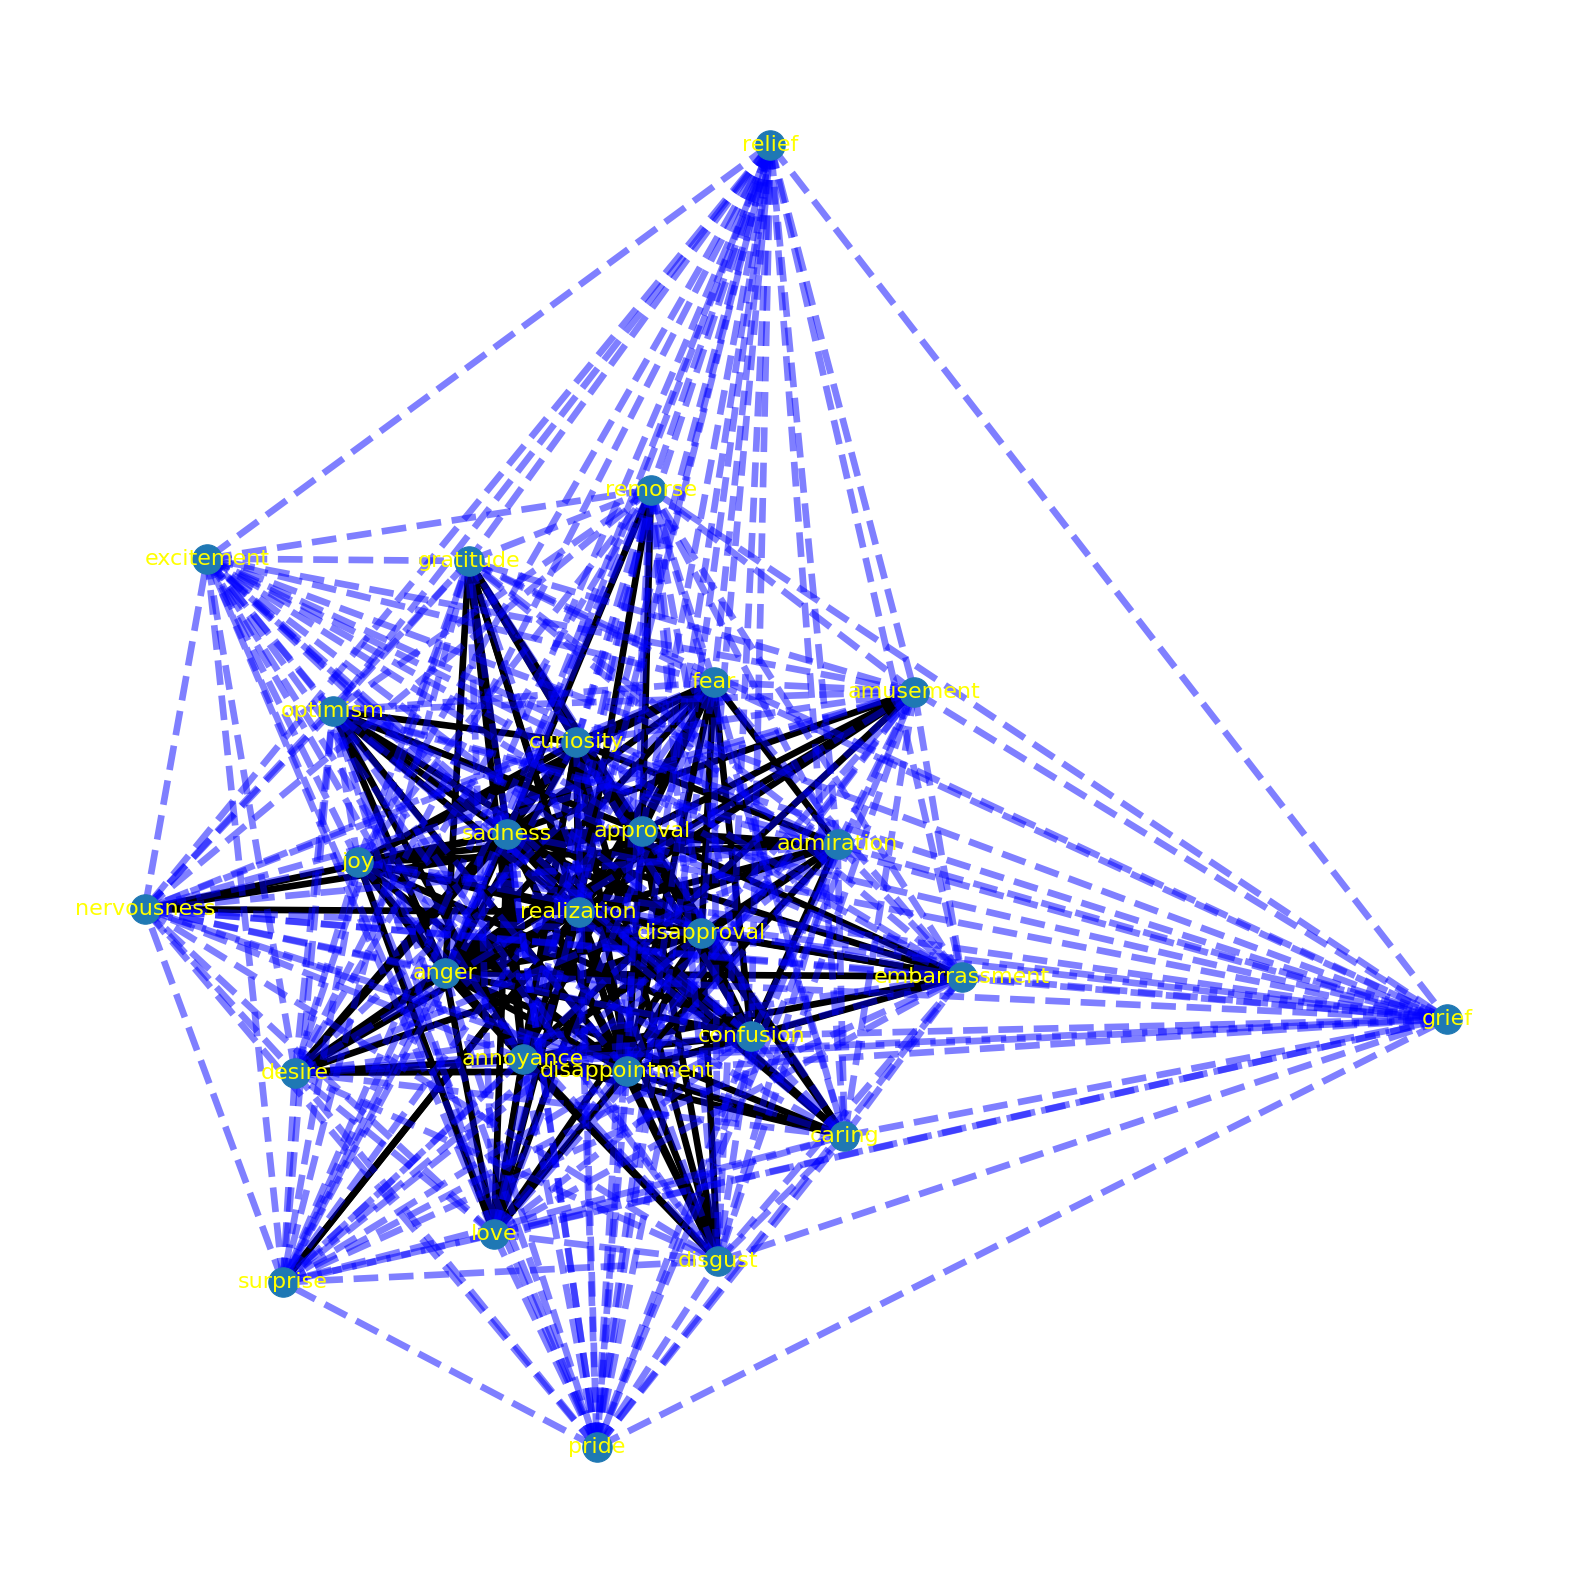

In [ ]:


if __name__ == '__main__' :
  G = nx.Graph()
  for key_index, weight in normal_counter.items() :
    G.add_edge(emo_organ_dicts[key_index[0]], emo_organ_dicts[key_index[1]], weight = weight)

  nx.write_gexf(G, "/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/emotion_graph.gexf")

  elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 5]
  esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 5]

  plt.figure(num=None, figsize=(20, 20), dpi=80)

  pos = nx.spring_layout(G, seed=7)
  # #nodes
  nx.draw_networkx_nodes(G, pos, node_size = 700)

  # #edges
  nx.draw_networkx_edges(G, pos, edgelist=elarge, width=6)
  nx.draw_networkx_edges(
      G, pos, edgelist=esmall, width=6, alpha=0.5, edge_color="b", style="dashed"
  )

  # node labels
  nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif", font_color = 'yellow')
  # edge weight labels
  # edge_labels = nx.get_edge_attributes(G, "weight")
  # nx.draw_networkx_edge_labels(G, pos, edge_labels)
  # nx.write_gexf(G, "/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/emotion_graph.gexf")

  plt.axis("off")
  plt.tight_layout()
  plt.show()

## EDA

In [ ]:
only_emo_counter_name = load_pkl("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/label_counter_dict.pkl")

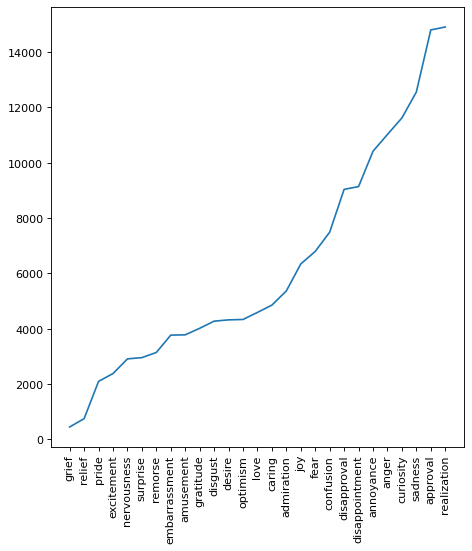

In [ ]:
only_emo_counter_name = dict(sorted(only_emo_counter_name.items(), key = lambda x:x[1]))
# print(only_emo_counter_name)
labels = only_emo_counter_name.keys()
emo_vals = only_emo_counter_name.values()
plt.figure(num=None, figsize=(6, 7), dpi=80)
plt.plot(labels, emo_vals)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# plt.savefig("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/figs/naive_dist.jpeg", dpi=300)
# plt.labels()

<ipython-input-62-07810c1755df>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(emo_labels, rotation =90)


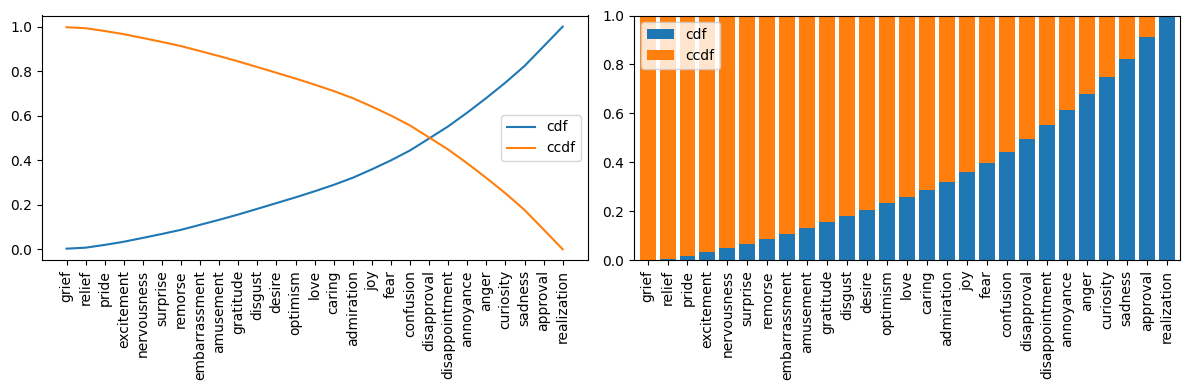

<Figure size 2000x2000 with 0 Axes>

In [ ]:
emo_labels = list(only_emo_counter_name.keys())
emo_vals = list(only_emo_counter_name.values())
cdf = np.cumsum(emo_vals) /np.sum(emo_vals)
ccdf = 1-cdf

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))
ax1.plot(emo_labels, cdf, label='cdf')
ax1.plot(emo_labels, ccdf, label='ccdf')
ax1.set_xticklabels(emo_labels, rotation =90)
ax1.legend()

ax2.bar(emo_labels, cdf, label='cdf')
ax2.bar(emo_labels, ccdf, bottom=cdf, label='ccdf')
ax2.margins(x=0.01)
ax2.set_xticks(emo_labels)
ax2.set_xticklabels(emo_labels, rotation = 90)
ax2.legend()

plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/reddit_redarc/reddit_asian_parents/figs/ccdf.jpeg", dpi = 300)

In [ ]:
cdf

array([0.00268302, 0.00716266, 0.01964972, 0.03381441, 0.0511321 ,
       0.06872345, 0.08742132, 0.10984925, 0.13233667, 0.15622806,
       0.18165431, 0.20736017, 0.23314931, 0.26045546, 0.28932621,
       0.32125477, 0.35898366, 0.39939558, 0.44394803, 0.49770367,
       0.55205421, 0.61399574, 0.6795543 , 0.74865254, 0.82332504,
       0.91134722, 1.        ])

In [ ]:
labels = only_emo_counter_name.keys()
emo_vals = only_emo_counter_name.values()

values, base =np.histogram(list(emo_vals), bins=40)

cumulative = np.cumsum(list(emo_vals))

plt.plot(base[:-1], len(list(emo_vals))-cumulative)